1. Import Labrary 

In [3]:
#1 Pandas yaitu library untuk memanipulasi data tabular
#2 Geopandas yaitu library untuk membaca dan mengolah data geojson
#3 Folium yaitu library untuk menampilkan peta yang interaktif
#4 Matplotlib yaitu library untuk menampilkan visualisasi berbentuk grafik
#5 Seaborn yaitu library untuk menampilkan visualisasi statistik
#6 Numpy yaitu library untuk analisis numerik
#7 Shapely yaitu library untuk membuat dan memanipulasi objek geometri polygon/ titik


import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from shapely.geometry import Polygon, Point

2. Load Geojson

In [4]:
geojson_path = r"C:\Users\IDEAPAD GAMING\Documents\Peta\Pelatihan\Mapid Webgist Bootcamp\Task\Task 4\Task_4\Labs\data_point_pluvial_flood_dataset.geojson"
df_flood = gpd.read_file(geojson_path)
print (df_flood.head())

          X         Y      Slope    Curvature       Aspect       TWI     FA  \
0  3.909444  7.443056  46.686142 -3.888000e+09   45.000000 -3.250368  147.0   
1  3.908611  7.442778  52.151768  1.296000e+09   60.945396 -4.313832   61.0   
2  3.908889  7.442778  66.484085  0.000000e+00   67.619865 -8.327622    1.0   
3  3.909167  7.442778  58.007183 -2.592000e+09   38.659809 -4.707937   51.0   
4  3.909444  7.442778  60.503792 -1.296000e+09  351.869904 -5.985817   15.0   

   Drainage    Rainfall     SUSCEP                 geometry  
0  228.8528  101.515616  Very_High  POINT (3.90944 7.44306)  
1  229.6781   80.409863  Very_High  POINT (3.90861 7.44278)  
2  230.5920   78.986849  Very_High  POINT (3.90889 7.44278)  
3  235.4210   81.953151  Very_High  POINT (3.90917 7.44278)  
4  234.4346   85.866027  Very_High  POINT (3.90944 7.44278)  


In [5]:
df_flood

,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall,SUSCEP,geometry
0,3.909444,7.443056,46.686142,-3.888000e+09,45.000000,-3.250368,147.0,228.8528,101.515616,Very_High,POINT (3.90944 7.44306)
1,3.908611,7.442778,52.151768,1.296000e+09,60.945396,-4.313832,61.0,229.6781,80.409863,Very_High,POINT (3.90861 7.44278)
2,3.908889,7.442778,66.484085,0.000000e+00,67.619865,-8.327622,1.0,230.5920,78.986849,Very_High,POINT (3.90889 7.44278)
3,3.909167,7.442778,58.007183,-2.592000e+09,38.659809,-4.707937,51.0,235.4210,81.953151,Very_High,POINT (3.90917 7.44278)
4,3.909444,7.442778,60.503792,-1.296000e+09,351.869904,-5.985817,15.0,234.4346,85.866027,Very_High,POINT (3.90944 7.44278)
...,...,...,...,...,...,...,...,...,...,...,...
144396,3.864167,7.311667,70.837776,1.296000e+09,272.489563,-8.552538,1.0,211.7292,63.087945,Low,POINT (3.86417 7.31167)
144397,3.864444,7.311667,72.578880,1.296000e+09,295.559967,-9.347733,0.0,220.4144,60.489041,Moderate,POINT (3.86444 7.31167)
144398,3.864722,7.311667,70.667946,6.480000e+09,322.125031,-9.236161,0.0,216.3101,62.886849,Low,POINT (3.86472 7.31167)
144399,3.859722,7.311389,61.980232,1.296000e+09,183.814072,-8.819514,0.0,214.3301,66.044932,Low,POINT (3.85972 7.31139)


3. Struktur data

In [6]:
print("A. Data Frame")
print(df_flood.info())

A. Data Frame
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 144401 entries, 0 to 144400
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   X           144401 non-null  float64 
 1   Y           144401 non-null  float64 
 2   Slope       144119 non-null  float64 
 3   Curvature   144401 non-null  float64 
 4   Aspect      144401 non-null  float64 
 5   TWI         144401 non-null  float64 
 6   FA          144401 non-null  float64 
 7   Drainage    144401 non-null  float64 
 8   Rainfall    144401 non-null  float64 
 9   SUSCEP      144401 non-null  str     
 10  geometry    144401 non-null  geometry
dtypes: float64(9), geometry(1), str(1)
memory usage: 12.1 MB
None


In [7]:
print("B. Statistik Deskriptif:")
print(df_flood.describe())

B. Statistik Deskriptif:
                   X              Y         Slope    Curvature         Aspect  \
count  144401.000000  144401.000000  1.441190e+05  1.444010e+05  1.444010e+05   
mean        3.891534       7.374551 -2.502788e+35 -8.342043e+35 -1.673122e+35   
std         0.027887       0.032459  9.225150e+36  1.682769e+37  7.543591e+36   
min         3.831111       7.311389 -3.402823e+38 -3.402823e+38 -3.402823e+38   
25%         3.868889       7.348333  5.105756e+01 -2.592000e+09  1.013099e+02   
50%         3.891667       7.374167  6.198023e+01  0.000000e+00  1.894623e+02   
75%         3.913611       7.400278  6.916712e+01  2.592000e+09  2.700000e+02   
max         3.954444       7.443056  8.657541e+01  3.888000e+10  3.591449e+02   

                TWI            FA       Drainage       Rainfall  
count  1.444010e+05  1.444010e+05  144401.000000  144401.000000  
mean  -2.120858e+34 -2.120858e+35     219.714542      74.786932  
std    2.686356e+36  8.492619e+36       7.05792

         #Outlier 

In [8]:
df_flood[(df_flood['FA']>=0)]

,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall,SUSCEP,geometry
0,3.909444,7.443056,46.686142,-3.888000e+09,45.000000,-3.250368,147.0,228.8528,101.515616,Very_High,POINT (3.90944 7.44306)
1,3.908611,7.442778,52.151768,1.296000e+09,60.945396,-4.313832,61.0,229.6781,80.409863,Very_High,POINT (3.90861 7.44278)
2,3.908889,7.442778,66.484085,0.000000e+00,67.619865,-8.327622,1.0,230.5920,78.986849,Very_High,POINT (3.90889 7.44278)
3,3.909167,7.442778,58.007183,-2.592000e+09,38.659809,-4.707937,51.0,235.4210,81.953151,Very_High,POINT (3.90917 7.44278)
4,3.909444,7.442778,60.503792,-1.296000e+09,351.869904,-5.985817,15.0,234.4346,85.866027,Very_High,POINT (3.90944 7.44278)
...,...,...,...,...,...,...,...,...,...,...,...
144396,3.864167,7.311667,70.837776,1.296000e+09,272.489563,-8.552538,1.0,211.7292,63.087945,Low,POINT (3.86417 7.31167)
144397,3.864444,7.311667,72.578880,1.296000e+09,295.559967,-9.347733,0.0,220.4144,60.489041,Moderate,POINT (3.86444 7.31167)
144398,3.864722,7.311667,70.667946,6.480000e+09,322.125031,-9.236161,0.0,216.3101,62.886849,Low,POINT (3.86472 7.31167)
144399,3.859722,7.311389,61.980232,1.296000e+09,183.814072,-8.819514,0.0,214.3301,66.044932,Low,POINT (3.85972 7.31139)


In [9]:
df_flood_final=df_flood[(df_flood['Slope']>=0)]

        #Struktur Data Setelah Outlier

In [10]:
print("A. Data Frame")
print(df_flood_final.info())

A. Data Frame
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 144013 entries, 0 to 144400
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   X           144013 non-null  float64 
 1   Y           144013 non-null  float64 
 2   Slope       144013 non-null  float64 
 3   Curvature   144013 non-null  float64 
 4   Aspect      144013 non-null  float64 
 5   TWI         144013 non-null  float64 
 6   FA          144013 non-null  float64 
 7   Drainage    144013 non-null  float64 
 8   Rainfall    144013 non-null  float64 
 9   SUSCEP      144013 non-null  str     
 10  geometry    144013 non-null  geometry
dtypes: float64(9), geometry(1), str(1)
memory usage: 13.2 MB
None


In [43]:
print("B. Statistik Deskriptif:")
print(df_flood_final.describe())

B. Statistik Deskriptif:
                   X              Y          Slope    Curvature   \
count  144013.000000  144013.000000  144013.000000  1.440130e+05   
mean        3.891544       7.374558      58.183881 -2.546770e+06   
std         0.027877       0.032503      15.157870  4.010003e+09   
min         3.831111       7.311389       0.000000 -3.499200e+10   
25%         3.868889       7.348056      51.340191 -2.592000e+09   
50%         3.891667       7.374167      61.980232  0.000000e+00   
75%         3.913611       7.400556      69.167122  2.592000e+09   
max         3.954444       7.443056      86.575409  3.888000e+10   

              Aspect            TWI             FA       Drainage  \
count  144013.000000  144013.000000  144013.000000  144013.000000   
mean      184.464709      -7.342037    1203.806434     219.714405   
std       101.419126       2.084627   19834.499573       7.057898   
min        -1.000000     -10.815885       0.000000     203.729300   
25%       101.309

In [11]:
df_flood_final

,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall,SUSCEP,geometry
0,3.909444,7.443056,46.686142,-3.888000e+09,45.000000,-3.250368,147.0,228.8528,101.515616,Very_High,POINT (3.90944 7.44306)
1,3.908611,7.442778,52.151768,1.296000e+09,60.945396,-4.313832,61.0,229.6781,80.409863,Very_High,POINT (3.90861 7.44278)
2,3.908889,7.442778,66.484085,0.000000e+00,67.619865,-8.327622,1.0,230.5920,78.986849,Very_High,POINT (3.90889 7.44278)
3,3.909167,7.442778,58.007183,-2.592000e+09,38.659809,-4.707937,51.0,235.4210,81.953151,Very_High,POINT (3.90917 7.44278)
4,3.909444,7.442778,60.503792,-1.296000e+09,351.869904,-5.985817,15.0,234.4346,85.866027,Very_High,POINT (3.90944 7.44278)
...,...,...,...,...,...,...,...,...,...,...,...
144396,3.864167,7.311667,70.837776,1.296000e+09,272.489563,-8.552538,1.0,211.7292,63.087945,Low,POINT (3.86417 7.31167)
144397,3.864444,7.311667,72.578880,1.296000e+09,295.559967,-9.347733,0.0,220.4144,60.489041,Moderate,POINT (3.86444 7.31167)
144398,3.864722,7.311667,70.667946,6.480000e+09,322.125031,-9.236161,0.0,216.3101,62.886849,Low,POINT (3.86472 7.31167)
144399,3.859722,7.311389,61.980232,1.296000e+09,183.814072,-8.819514,0.0,214.3301,66.044932,Low,POINT (3.85972 7.31139)


4. Visualisasi Distribusi Parameter

A. Histogram untuk Parameter Slope


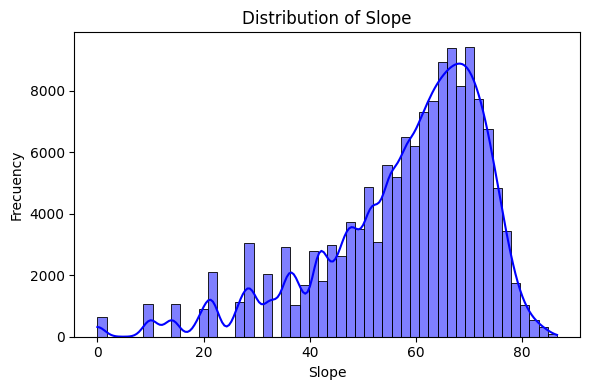

B. Histogram untuk Parameter Rainfall


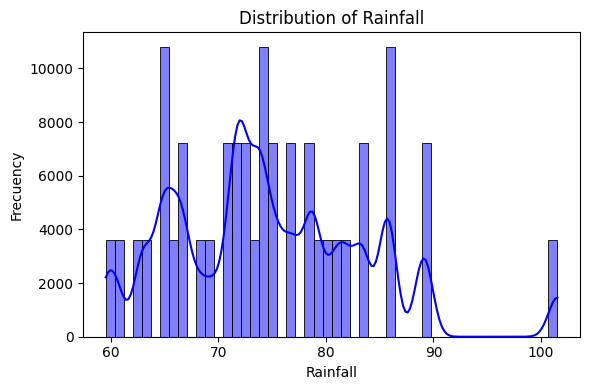

B. Histogram untuk Parameter TWI


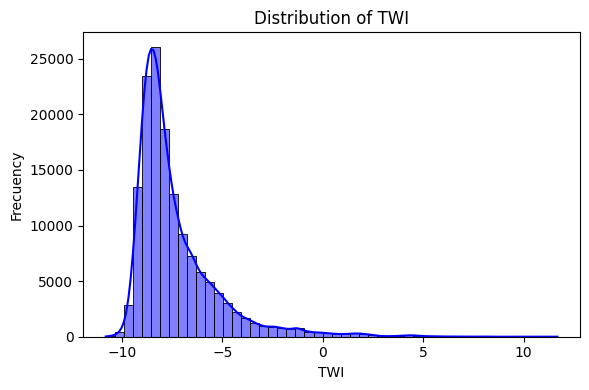

B. Histogram untuk Parameter Curvature


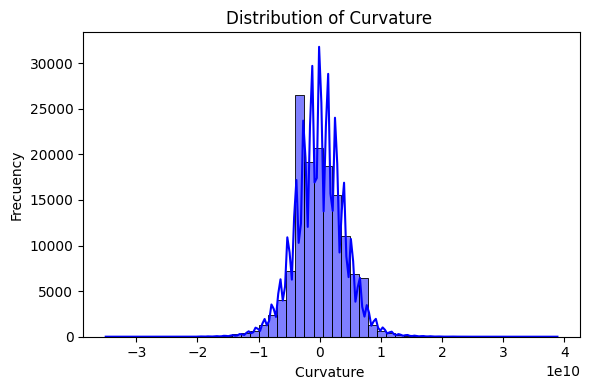

In [12]:
print("A. Histogram untuk Parameter Slope")
plt.figure(figsize=(6,4))
sns.histplot(df_flood_final['Slope'], bins=50, kde=True, color='blue')
plt.title('Distribution of Slope')
plt.xlabel('Slope')
plt.ylabel('Frecuency')
plt.tight_layout()
plt.show()

print("B. Histogram untuk Parameter Rainfall")
plt.figure(figsize=(6,4))
sns.histplot(df_flood_final['Rainfall'], bins=50, kde=True, color='blue')
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall')
plt.ylabel('Frecuency')
plt.tight_layout()
plt.show()

print("B. Histogram untuk Parameter TWI")
plt.figure(figsize=(6,4))
sns.histplot(df_flood_final['TWI'], bins=50, kde=True, color='blue')
plt.title('Distribution of TWI')
plt.xlabel('TWI')
plt.ylabel('Frecuency')
plt.tight_layout()
plt.show()

print("B. Histogram untuk Parameter Curvature")
plt.figure(figsize=(6,4))
sns.histplot(df_flood_final['Curvature '], bins=50, kde=True, color='blue')
plt.title('Distribution of Curvature ')
plt.xlabel('Curvature ')
plt.ylabel('Frecuency')
plt.tight_layout()
plt.show()


5. Analisis Kategori Suscreptibility

In [13]:
#A. Jumlah titik per kategori value_counts()
print(df_flood_final[['Drainage','SUSCEP']])

jumlah_per_kategori_SUSCEP= df_flood_final['SUSCEP'].value_counts()
print(jumlah_per_kategori_SUSCEP)


        Drainage     SUSCEP
0       228.8528  Very_High
1       229.6781  Very_High
2       230.5920  Very_High
3       235.4210  Very_High
4       234.4346  Very_High
...          ...        ...
144396  211.7292        Low
144397  220.4144   Moderate
144398  216.3101        Low
144399  214.3301        Low
144400  211.5915        Low

[144013 rows x 2 columns]
SUSCEP
Moderate     38013
High         34359
Low          32166
Very_High    23392
No_Flood     16083
Name: count, dtype: int64


C:\Users\IDEAPAD GAMING\AppData\Local\Temp\ipykernel_2372\2964857300.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SUSCEP', data=df_flood_final, palette='viridis')


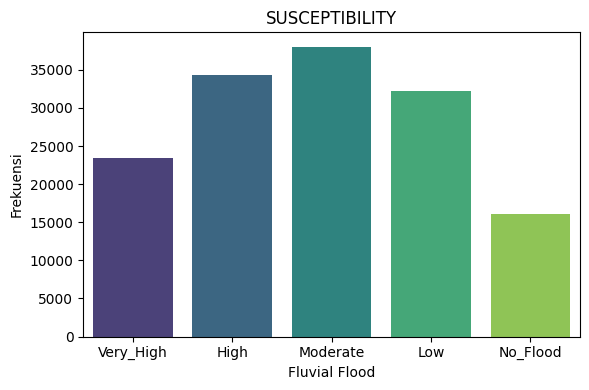

In [14]:
#B. Bar Chart
plt.figure(figsize=(6,4))
sns.countplot(x='SUSCEP', data=df_flood_final, palette='viridis')
plt.title('SUSCEPTIBILITY')
plt.xlabel('Fluvial Flood')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

6. ScatterPlot Hubungan Parameter

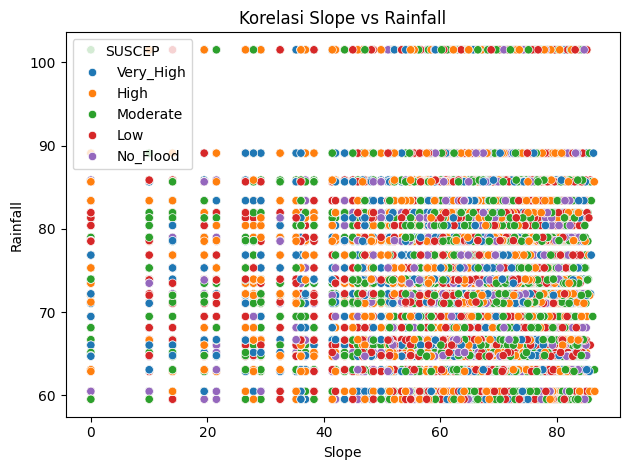

In [49]:
plt.Figure(figsize=(7,5))
sns.scatterplot(x='Slope', y='Rainfall', data=df_flood_final, hue='SUSCEP')
plt.title('Korelasi Slope vs Rainfall')
plt.xlabel('Slope')
plt.ylabel('Rainfall')
plt.tight_layout()
plt.show()

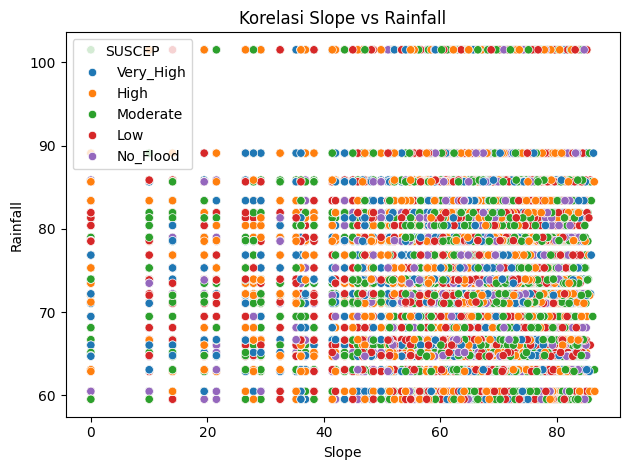

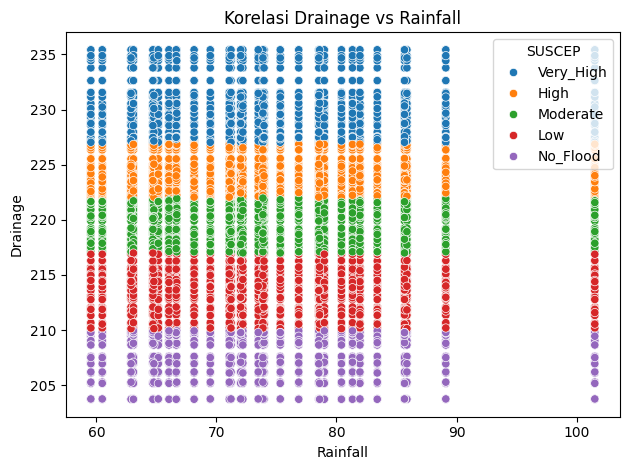

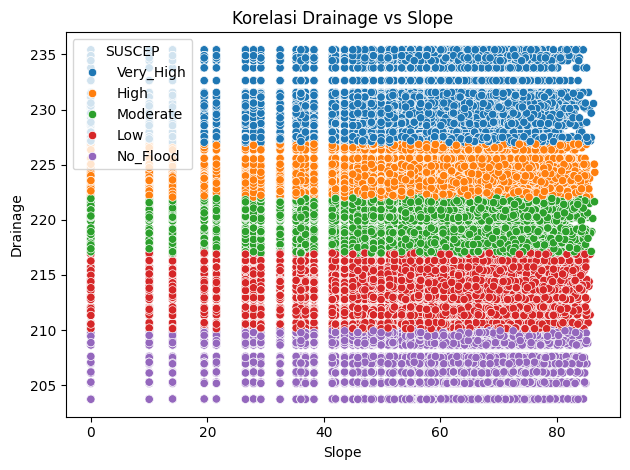

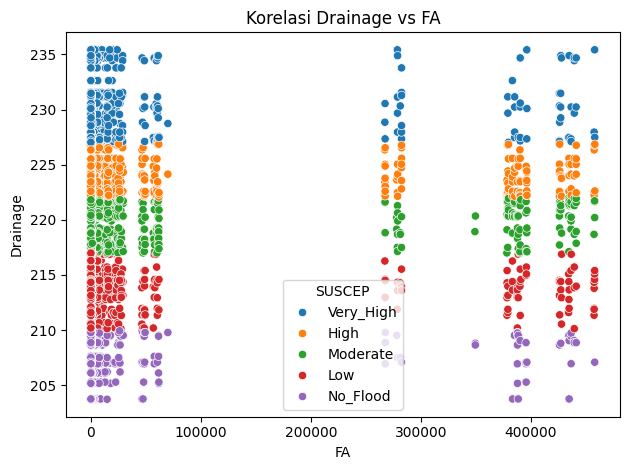

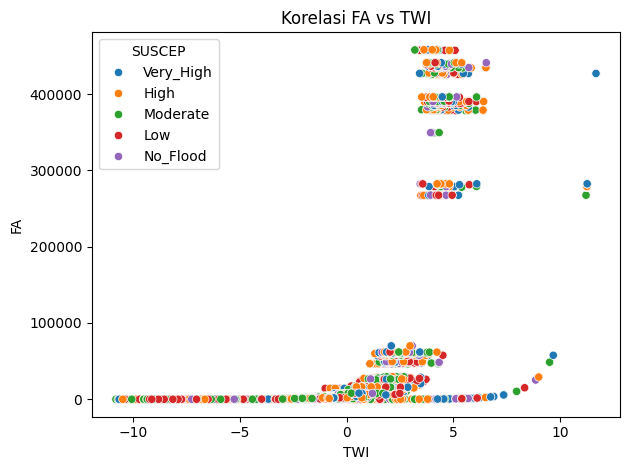

A. Hubungan antara Slope dan Rainfall terlihat tersebar merata artinya tidak ada pola linear atau tidak ada korelasi
B. Hubungan Rainfall, Slope, FA dengan Drainage Tidak terlihat pola hubungan linear yang jelas rainfall, Slope, FA dengan Drainage
C. Hubungan antara TWI dan FA, terlihat jika TWI meningkat FA juga ikut meningkat artinya terdapat korelasi, FA dan TWI tinggi cenderung masuk kategori High / Very_High susceptibility


In [151]:
#A. ScatterPlot Slope dan Rainfall
plt.Figure(figsize=(7,5))
sns.scatterplot(x='Slope', y='Rainfall', data=df_flood_final, hue='SUSCEP')
plt.title('Korelasi Slope vs Rainfall')
plt.xlabel('Slope')
plt.ylabel('Rainfall')
plt.tight_layout()
plt.show()

plt.Figure(figsize=(7,5))
sns.scatterplot(x='Rainfall', y='Drainage', data=df_flood_final, hue='SUSCEP')
plt.title('Korelasi Drainage vs Rainfall')
plt.xlabel('Rainfall')
plt.ylabel('Drainage')
plt.tight_layout()
plt.show()

plt.Figure(figsize=(7,5))
sns.scatterplot(x='Slope', y='Drainage', data=df_flood_final, hue='SUSCEP')
plt.title('Korelasi Drainage vs Slope')
plt.xlabel('Slope')
plt.ylabel('Drainage')
plt.tight_layout()
plt.show()

plt.Figure(figsize=(7,5))
sns.scatterplot(x='FA', y='Drainage', data=df_flood_final, hue='SUSCEP')
plt.title('Korelasi Drainage vs FA')
plt.xlabel('FA')
plt.ylabel('Drainage')
plt.tight_layout()
plt.show()

plt.Figure(figsize=(7,5))
sns.scatterplot(x='TWI', y='FA', data=df_flood_final, hue='SUSCEP')
plt.title('Korelasi FA vs TWI')
plt.xlabel('TWI')
plt.ylabel('FA')
plt.tight_layout()
plt.show()


#B. Apakah Ada Pola tertentu yangterlihat?
print('A. Hubungan antara Slope dan Rainfall terlihat tersebar merata artinya tidak ada pola linear atau tidak ada korelasi')
print('B. Hubungan Rainfall, Slope, FA dengan Drainage Tidak terlihat pola hubungan linear yang jelas rainfall, Slope, FA dengan Drainage')
print('C. Hubungan antara TWI dan FA, terlihat jika TWI meningkat FA juga ikut meningkat artinya terdapat korelasi, FA dan TWI tinggi cenderung masuk kategori High / Very_High susceptibility')

7. Heatmap Korelasi Parameter

Matriks Korelasi antar Parameter


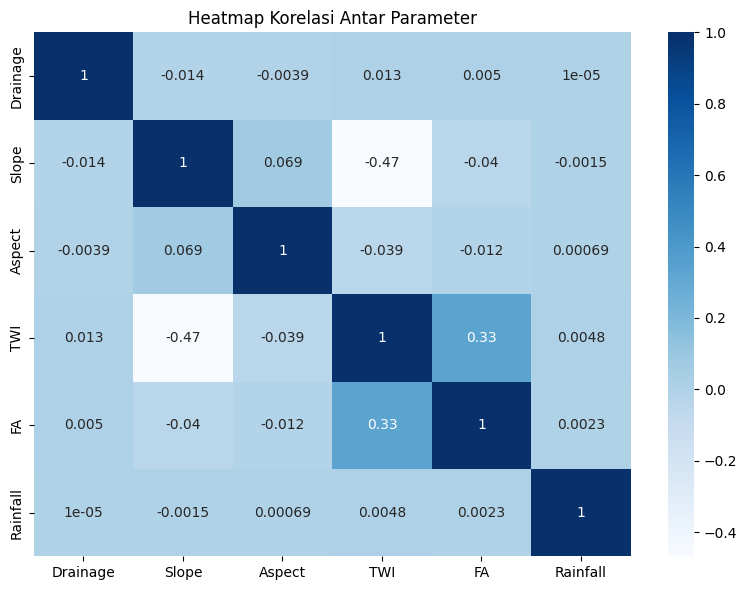

In [53]:
#A. Matriks Korelasi antar Parameter numerik
#B. Visualisasi HeatMap
print('Matriks Korelasi antar Parameter')
corr_matrix = df_flood_final[['Drainage','Slope','Aspect', 'TWI', 'FA', 'Rainfall']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title('Heatmap Korelasi Antar Parameter')
plt.tight_layout()
plt.show()

8. Peta Interaktif Titik Flood

In [85]:
#A.  5 titik acak
df_sampel = df_flood_final.sample(n=10, random_state=100)
print('10 Sampel Acak')
print(sampel)

10 Sampel Acak
               X         Y      Slope    Curvature       Aspect       TWI  \
4512    3.916389  7.431389  45.868252  0.000000e+00  345.963745 -7.525854   
41533   3.911111  7.396389  73.243797  0.000000e+00  160.201126 -8.290442   
115435  3.908333  7.342778  57.849022  1.296000e+09  225.000000 -8.653046   
97920   3.917222  7.355833  10.024988  2.592000e+09  225.000000 -1.693647   
102856  3.895000  7.352222  65.423981  2.592000e+09  300.963745 -8.971040   
102746  3.864444  7.352222  55.550098 -1.296000e+09  120.963753 -7.466962   
106379  3.920833  7.349722  66.484085 -5.184000e+09  157.619858 -7.411332   
7909    3.898889  7.426944  47.077755 -1.296000e+09  305.537689 -7.162667   
144140  3.860556  7.312778  42.031113 -2.592000e+09   33.690067 -6.138959   
3884    3.904167  7.432222  54.084713  2.592000e+09   95.194427 -8.511258   

           FA  Drainage    Rainfall     SUSCEP                 geometry  
4512      1.0  218.7961   68.140822   Moderate  POINT (3.91639 

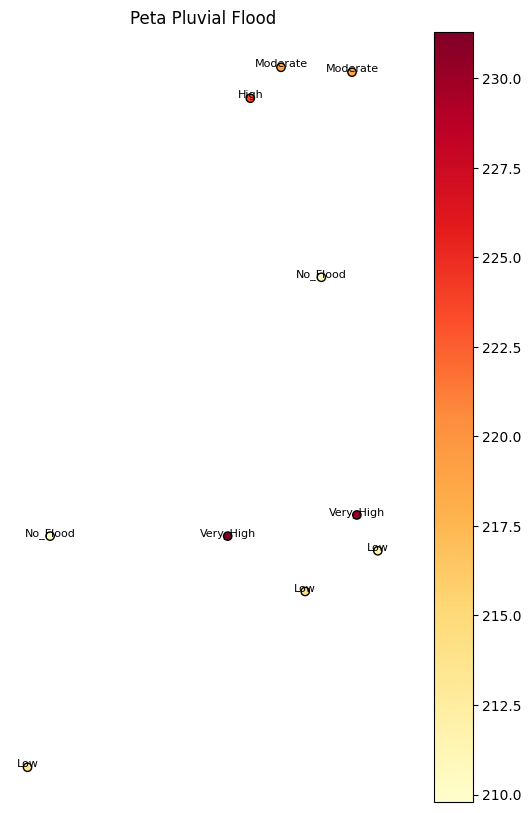

In [89]:
#B. Visualisasi Peta Interaktif
fig, ax = plt.subplots(figsize=(10,10))
df_sampel.plot(column='Drainage', ax=ax, legend=True, cmap='YlOrRd', edgecolor='black')
for idx, row in sampel.iterrows():
    ax.annotate(
        text=row['SUSCEP'],
        xy=(row['X'], row['Y']),
        ha='center',
        fontsize=8,
        color='black'
    )
plt.title('Peta Pluvial Flood')
plt.axis('off')
plt.show()

In [148]:
# C. Menambah Tooltip/ Popup
disp = [df_sampel['Y'].mean(), df_sampel['X'].mean()]
maps = folium.Map(location=disp, zoom_start=12, tiles='OpenStreetMap')

folium.GeoJson(df_sampel, style_function=lambda feature: {
    'fillcolor': '#3186cc',
    'color': 'Black',
    'Weight': 2,
    'fillOpacity': 0.5,},
tooltip=folium.GeoJsonTooltip(
        fields=['Slope', 'Curvature ', 'Aspect', 'TWI', 'FA', 'Rainfall', 'Drainage', 'SUSCEP'],
        aliases=['Slope:', 'Curvature:', 'Aspect:', 'TWI:', 'FA:', 'Rainfall:', 'Drainage:', 'SUSCEPTIBILITY:'],
        localize=True)
).add_to(maps)

# for idx, row in df_sampel.iterrows():
folium.Marker(
        location=[row['Y'], row['X']],
        popup=f"Slope: {row['Slope']}<br>Curvature: {row['Curvature ']}<br>Aspect: {row['Aspect']}<br>TWI: {row['TWI']}<br>FA: {row['FA']}<br>Rainfall: {row['Rainfall']}<br>Drainage: {row['Drainage']}<br>SUSCEPTIBILITY: {row['SUSCEP']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(maps)

In [149]:
#D. Save file HTML
maps.save('MuhamadLutfiFirdaus_Webgis_Task4.html')
